# XAI-Guided Tabular Modeling: From CNN Explanations to Linear Interpretability

This notebook implements the final stage of our pipeline: using deep explainability results to build an interpretable, classical machine-learning model. After analyzing our CNNs with Grad-CAM, Grad-CAM++, PGD attacks, and deletion/insertion curves, we identify the most discriminative frequency regions in the STFT domain. These high-saliency bands are then converted into compact tabular features extracted directly from the raw 1-second vibration segments.

**1. Explainability-driven band selection**  
Using the Grad-CAM and Grad-CAM++ frequency curves computed in Notebook 1, we detect consistent high-saliency regions across all classes and derive continuous frequency bands. Each band is optionally subdivided into smaller sub-bands to increase feature granularity.

**2. Feature extraction from raw signals**  
For every segment we compute five descriptors per band (mean, RMS, variance, skewness, kurtosis) using numeric STFT magnitudes. This produces a lightweight tabular dataset with shape (N_samples × N_features).

**3. Logistic Regression training**  
We standardize all features and train a multinomial Logistic Regression classifier. Despite being a simple linear model, the accuracy is extremely high because features were chosen using CNN explainability.

**4. Global + local interpretability**  
We compute permutation importance to identify the most influential frequency-band features, and we generate per-sample logit-contribution bar plots for all classes. These reveal exactly which band statistics push a prediction toward or away from a class.

This notebook closes the pipeline by connecting deep-model insights to a fully interpretable classical model with transparent decision mechanisms.


In [2]:
# 0. Imports & Global Config

import os
from pathlib import Path
import numpy as np
from PIL import Image
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from tqdm import tqdm
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Paths (all relative to the project folder where this notebook lives)
PROJECT_ROOT = Path.cwd()

# Organized data (from Notebook 1) – mostly for reference
DATA_ROOT = PROJECT_ROOT / "data_CWRU_Organized"

# Image folders (EXACTLY like the training notebook)
IMG_ROOT  = PROJECT_ROOT / "Images_STFT_CWT"
DATA_STFT = IMG_ROOT / "STFT"
DATA_CWT  = IMG_ROOT / "CWT"

print("DATA_STFT exists:", DATA_STFT.exists())
print("DATA_CWT exists:", DATA_CWT.exists())

# Folder where models trained in the previous notebook are stored
RESULTS_ROOT = PROJECT_ROOT / "model_training_results"
MODEL_ROOT   = RESULTS_ROOT / "models"

print("MODEL_ROOT:", MODEL_ROOT)

# Folder where ALL XAI outputs (figures + arrays) will be stored
XAI_ROOT = PROJECT_ROOT / "xai_outputs"
XAI_ROOT.mkdir(parents=True, exist_ok=True)
print("XAI_ROOT:", XAI_ROOT)

# Output folder for tabular models
TABULAR_ROOT = PROJECT_ROOT / "tabular_models_outputs"
TABULAR_ROOT.mkdir(parents=True, exist_ok=True)
print("TABULAR_ROOT     :", TABULAR_ROOT)


Using device: cuda
DATA_STFT exists: True
DATA_CWT exists: True
MODEL_ROOT: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\model_training_results\models
XAI_ROOT: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\xai_outputs
TABULAR_ROOT     : C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs


In [3]:
# 1. Image Transforms

# Same transform used during training / explainability 
img_transform_model = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

# Additional transform WITHOUT normalization, for feature extraction later
img_transform_plain = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),   # values in [0,1] from PNG
])

def load_image_for_model(path: Path):
    img = Image.open(path).convert("RGB")
    return img_transform_model(img)

def load_image_plain(path: Path):
    img = Image.open(path).convert("RGB")
    return img_transform_plain(img)


In [4]:
# 2. Chen 2D-CNN (exact as training)

class Chen2DCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 4, kernel_size=9, stride=2, padding=4)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=9, stride=2, padding=4)
        self.pool2 = nn.MaxPool2d(kernel_size=4, stride=4)

        self.conv3 = nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=2)
        self.conv4 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Compute flatten dimension exactly as you did
        with torch.no_grad():
            x = torch.zeros(1, in_channels, 256, 256)
            x = self.pool2(F.relu(self.conv2(F.relu(self.conv1(x)))))
            x = self.pool4(F.relu(self.conv4(F.relu(self.conv3(x)))))
            flat_dim = x.numel()

        self.fc1 = nn.Linear(flat_dim, 128)
        self.fc2 = nn.Linear(128, 32)
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool4(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)


In [5]:
# 3. Load trained STFT

stft_model_path = MODEL_ROOT / "CNN_STFT.pth"

print("STFT model path:", stft_model_path)

assert stft_model_path.is_file(), f"STFT model not found at: {stft_model_path}"

def load_chen_model(weight_path, in_channels=3, num_classes=4):
    """
    Load Chen-style 2D CNN with pretrained weights.
    """
    model = Chen2DCNN(in_channels=in_channels, num_classes=num_classes)
    
    # If your PyTorch version supports weights_only, keep it;
    # otherwise, remove weights_only=True.
    state = torch.load(weight_path, map_location=device, weights_only=True)
    
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model

stft_model = load_chen_model(stft_model_path)

print("Model loaded.")


STFT model path: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\model_training_results\models\CNN_STFT.pth
Model loaded.


class_to_idx: {'Ball': 0, 'Baseline': 1, 'Inner': 2, 'Outer': 3}
#train images: 2052
#test images: 879
STFT TEST loss=0.0003, acc=1.0000


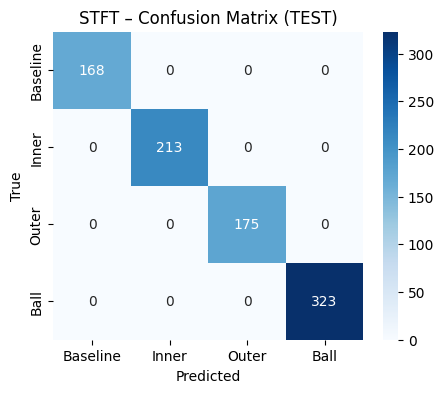


Classification Report:

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00       168
       Inner       1.00      1.00      1.00       213
       Outer       1.00      1.00      1.00       175
        Ball       1.00      1.00      1.00       323

    accuracy                           1.00       879
   macro avg       1.00      1.00      1.00       879
weighted avg       1.00      1.00      1.00       879



In [7]:
# 4. Build STFT TRAIN and TEST loaders (ImageFolder)

from torchvision.datasets import ImageFolder

stft_train_dir = DATA_STFT / "train"
stft_test_dir  = DATA_STFT / "test"

stft_train_ds = ImageFolder(root=stft_train_dir, transform=img_transform_model)
stft_test_ds  = ImageFolder(root=stft_test_dir,  transform=img_transform_model)

stft_train_loader = DataLoader(
    stft_train_ds,
    batch_size=1,        # batch_size=1 is simpler for Grad-CAM
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

stft_test_loader = DataLoader(
    stft_test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

print("class_to_idx:", stft_train_ds.class_to_idx)
print("#train images:", len(stft_train_ds))
print("#test images:", len(stft_test_ds))

# Test the model

criterion = nn.CrossEntropyLoss()
all_targets = []
all_preds = []
running_loss = 0.0

stft_model.eval()

with torch.no_grad():
    for inputs, targets in stft_test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = stft_model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)

        all_targets.append(targets.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

y_true = np.concatenate(all_targets)
y_pred = np.concatenate(all_preds)

test_loss = running_loss / len(stft_test_ds)
test_acc = (y_true == y_pred).mean()

print(f"STFT TEST loss={test_loss:.4f}, acc={test_acc:.4f}")

# Confusion Matrix
CLASS_NAMES = ["Baseline", "Inner", "Outer", "Ball"]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("STFT – Confusion Matrix (TEST)")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


In [8]:
# 5. Grad-CAM and Grad-CAM++ implementations

class GradCAM:
    """
    Standard Grad-CAM:
      weights_k = GAP_ij( dY/dA_kij )
      CAM = ReLU( Σ_k weights_k * A_k )
    """
    def __init__(self, model: nn.Module, target_layer_name: str = "conv4"):
        self.model = model
        self.model.eval()
        self.target_layer_name = target_layer_name

        self.activations = None   # feature maps A
        self.gradients   = None   # gradients dY/dA

        target_layer = getattr(self.model, self.target_layer_name)
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()          # (N,C,H',W')

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach() # (N,C,H',W')

    def generate(self, x: torch.Tensor, class_idx: int = None):
        """
        x        : (1, C, H, W) normalized input
        class_idx: target class index. If None, uses argmax prediction.
        returns  : Grad-CAM heatmap (H', W') in [0,1]
        """
        self.model.zero_grad()

        out = self.model(x)  # (1, num_classes)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        score = out[0, class_idx]
        score.backward(retain_graph=False)

        A = self.activations   # (1,C,H',W')
        G = self.gradients     # (1,C,H',W')

        # Global-average-pool over spatial dims → weights
        weights = G.mean(dim=(2, 3), keepdim=True)      # (1,C,1,1)

        # Linear combination of feature maps
        cam = (weights * A).sum(dim=1, keepdim=True)    # (1,1,H',W')
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()  # (H', W')
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam


class GradCAMPlusPlus:
    """
    Grad-CAM++:
      alpha_kij = g^2 / (2 g^2 + A_ij g^3 + eps)
      weights_k = Σ_ij alpha_kij * ReLU(g_kij)
      CAM = ReLU( Σ_k weights_k * A_k )
    """
    def __init__(self, model: nn.Module, target_layer_name: str = "conv4"):
        self.model = model
        self.model.eval()
        self.target_layer_name = target_layer_name

        self.activations = None
        self.gradients   = None

        target_layer = getattr(self.model, self.target_layer_name)
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()          # (N,C,H',W')

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach() # (N,C,H',W')

    def generate(self, x: torch.Tensor, class_idx: int = None):
        """
        x        : (1, C, H, W) normalized input
        class_idx: target class index. If None, uses argmax prediction.
        returns  : Grad-CAM++ heatmap (H', W') in [0,1]
        """
        self.model.zero_grad()

        out = self.model(x)  # (1, num_classes)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        score = out[0, class_idx]
        score.backward(retain_graph=False)

        A = self.activations   # (1,C,H',W')
        G = self.gradients     # (1,C,H',W')

        grads2 = G * G
        grads3 = grads2 * G

        A_sum = A.sum(dim=(2, 3), keepdim=True)        # (1,C,1,1)
        eps = 1e-8

        alpha = grads2 / (2 * grads2 + A_sum * grads3 + eps)
        relu_grads = F.relu(G)

        weights = (alpha * relu_grads).sum(dim=(2, 3), keepdim=True)  # (1,C,1,1)

        cam = (weights * A).sum(dim=1, keepdim=True)   # (1,1,H',W')
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam

In [9]:
# 6. Compute frequency saliency (Grad-CAM & Grad-CAM++) on STFT TRAIN

gc_stft   = GradCAM(stft_model,   target_layer_name="conv4")
gcpp_stft = GradCAMPlusPlus(stft_model, target_layer_name="conv4")

freq_saliencies_gc   = []  # list of np.array(H')
freq_saliencies_gcpp = []  # list of np.array(H')
freq_labels          = []  # integer class labels (0..3)

from tqdm import tqdm

for img_tensor, label in tqdm(stft_train_loader, desc="Grad-CAM / Grad-CAM++ on train"):
    img_tensor = img_tensor.to(device)           # (1,3,256,256)
    img_tensor.requires_grad_(True)

    # Forward to get predicted class
    logits = stft_model(img_tensor)
    pred_cls = logits.argmax(dim=1).item()

    # Grad-CAM heatmap 
    cam_gc = gc_stft.generate(img_tensor, class_idx=pred_cls)

    # Grad-CAM++ heatmap 
    cam_gcpp = gcpp_stft.generate(img_tensor, class_idx=pred_cls)

    # Ensure both are 256x256 (for consistent frequency axis)
    for name, cam in (("gc", cam_gc), ("gcpp", cam_gcpp)):
        if cam.shape != (256, 256):
            cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)    # (1,1,H,W)
            cam_t = F.interpolate(cam_t, size=(256, 256),
                                  mode="bilinear", align_corners=False)
            if name == "gc":
                cam_gc = cam_t.squeeze().cpu().numpy()
            else:
                cam_gcpp = cam_t.squeeze().cpu().numpy()

    # Collapse over time dimension (axis=1 → width) to get saliency vs frequency
    freq_curve_gc   = cam_gc.mean(axis=1)     # (256,)
    freq_curve_gcpp = cam_gcpp.mean(axis=1)   # (256,)

    freq_saliencies_gc.append(freq_curve_gc.astype(np.float32))
    freq_saliencies_gcpp.append(freq_curve_gcpp.astype(np.float32))
    freq_labels.append(label.item())

freq_saliencies_gc   = np.stack(freq_saliencies_gc)      # (N_train, 256)
freq_saliencies_gcpp = np.stack(freq_saliencies_gcpp)    # (N_train, 256)
freq_labels          = np.array(freq_labels)             # (N_train,)

print("freq_saliencies_gc   shape:", freq_saliencies_gc.shape)
print("freq_saliencies_gcpp shape:", freq_saliencies_gcpp.shape)
print("freq_labels          shape:", freq_labels.shape)

Grad-CAM / Grad-CAM++ on train: 100%|██████████████████████████████████████████████| 2052/2052 [00:29<00:00, 69.97it/s]


freq_saliencies_gc   shape: (2052, 256)
freq_saliencies_gcpp shape: (2052, 256)
freq_labels          shape: (2052,)


idx_to_class: {0: 'Ball', 1: 'Baseline', 2: 'Inner', 3: 'Outer'}


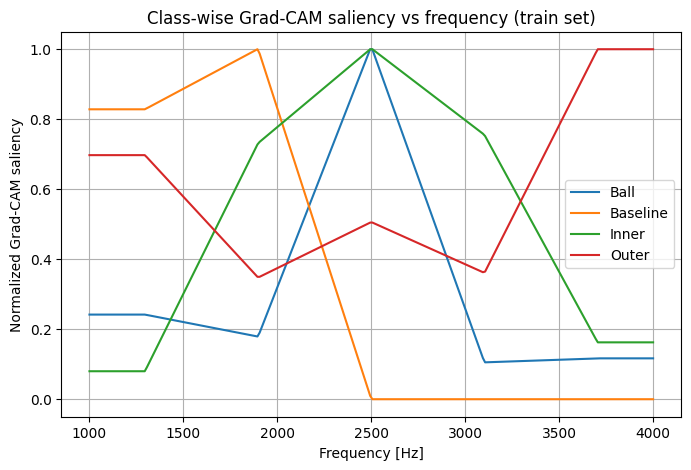

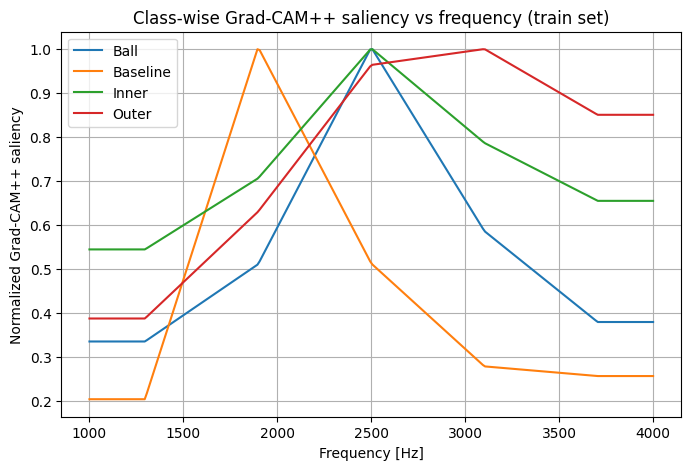

Using Grad-CAM saliency curves for band selection / pruning.


In [10]:
# 7. Class-wise mean saliency curves + frequency axis (GC & GC++)

class_to_idx = stft_train_ds.class_to_idx   # e.g. {'Ball':0, 'Baseline':1, 'Inner':2, 'Outer':3}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print("idx_to_class:", idx_to_class)

H = 256
fmin, fmax = 1000.0, 4000.0
freq_axis = np.linspace(fmin, fmax, H)   # approximate mapping row → frequency [Hz]

num_classes = len(class_to_idx)

# Grad-CAM curves 
mean_curves_gc = []

plt.figure(figsize=(8,5))
for c in range(num_classes):
    mask     = (freq_labels == c)
    curves_c = freq_saliencies_gc[mask]           # (Nc, 256)
    mean_c   = curves_c.mean(axis=0)
    if mean_c.max() > 0:
        mean_c = mean_c / mean_c.max()
    mean_curves_gc.append(mean_c)
    plt.plot(freq_axis, mean_c, label=idx_to_class[c])

plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Grad-CAM saliency")
plt.title("Class-wise Grad-CAM saliency vs frequency (train set)")
plt.legend()
plt.grid(True)
GC_FIG_PATH = TABULAR_ROOT / "class-wise_GradCAM_saliency_frequency.png"
plt.savefig(GC_FIG_PATH, dpi=300)
plt.show()

mean_curves_gc = np.stack(mean_curves_gc)   # (num_classes, 256)

# Grad-CAM++ curves
mean_curves_gcpp = []

plt.figure(figsize=(8,5))
for c in range(num_classes):
    mask     = (freq_labels == c)
    curves_c = freq_saliencies_gcpp[mask]        # (Nc, 256)
    mean_c   = curves_c.mean(axis=0)
    if mean_c.max() > 0:
        mean_c = mean_c / mean_c.max()
    mean_curves_gcpp.append(mean_c)
    plt.plot(freq_axis, mean_c, label=idx_to_class[c])

plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Grad-CAM++ saliency")
plt.title("Class-wise Grad-CAM++ saliency vs frequency (train set)")
plt.legend()
plt.grid(True)
GCPP_FIG_PATH = TABULAR_ROOT / "class-wise_GradCAMpp_saliency_frequency.png"
plt.savefig(GCPP_FIG_PATH, dpi=300)
plt.show()

mean_curves_gcpp = np.stack(mean_curves_gcpp)   # (num_classes, 256)

# Choose which method to use for pruning (GC or GCPP) 
METHOD_FOR_PRUNING = "GC"   # CHANGE "GCPP" FOR Grad-CAM++

if METHOD_FOR_PRUNING == "GC":
    freq_saliencies = freq_saliencies_gc
    mean_curves     = mean_curves_gc
    print("Using Grad-CAM saliency curves for band selection / pruning.")
else:
    freq_saliencies = freq_saliencies_gcpp
    mean_curves     = mean_curves_gcpp
    print("Using Grad-CAM++ saliency curves for band selection / pruning.")


In [11]:
# 8. Derive frequency bands quantitatively from mean_curves

percentile = 90  # SET THRESHOLD     
min_band_width_hz = 200.0  # discard very narrow bands (< 200 Hz)

H = mean_curves.shape[1]

def curves_to_bands(curves, freq_axis, percentile, min_width_hz):
    bands = []

    for c in range(curves.shape[0]):
        curve = curves[c]
        thr = np.percentile(curve[curve > 0], percentile)
        mask = curve >= thr

        # find contiguous segments where mask==True
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        # split into contiguous groups
        start = idx[0]
        prev = idx[0]
        for k in idx[1:]:
            if k == prev + 1:
                prev = k
            else:
                # close previous segment
                f_start = freq_axis[start]
                f_end   = freq_axis[prev]
                if f_end - f_start >= min_width_hz:
                    bands.append((f_start, f_end))
                # start new
                start = k
                prev  = k
        # last segment
        f_start = freq_axis[start]
        f_end   = freq_axis[prev]
        if f_end - f_start >= min_width_hz:
            bands.append((f_start, f_end))

    # merge overlapping bands across classes
    if not bands:
        return []

    bands = sorted(bands, key=lambda x: x[0])
    merged = [bands[0]]
    for (a_start, a_end) in bands[1:]:
        last_start, last_end = merged[-1]
        if a_start <= last_end:   # overlap
            merged[-1] = (last_start, max(last_end, a_end))
        else:
            merged.append((a_start, a_end))
    return merged

BANDS_HZ = curves_to_bands(mean_curves, freq_axis,
                           percentile=percentile,
                           min_width_hz=min_band_width_hz)

print("Derived frequency bands (Hz):")
for b in BANDS_HZ:
    print(f"  {b[0]:.1f} – {b[1]:.1f}")


Derived frequency bands (Hz):
  1694.1 – 1929.4
  2341.2 – 2658.8
  3705.9 – 4000.0


In [12]:
# 9. Convert ALL BANDS_HZ into multiple sub-bands 

# Number of sub-bands per detected saliency band
N_SUBBANDS_PER_BAND = 1   # e.g., 1 = no split; 2,3,... for finer bands

print("High-saliency bands detected by", METHOD_FOR_PRUNING, ":")
for b in BANDS_HZ:
    print(f"  {b[0]:.1f} – {b[1]:.1f} Hz")
print()

# Split *each* band into N_SUBBANDS_PER_BAND equal sub-bands
BANDS_HZ_SUB = []

for (fmin_b, fmax_b) in BANDS_HZ:
    edges = np.linspace(fmin_b, fmax_b, N_SUBBANDS_PER_BAND + 1)

    for i in range(N_SUBBANDS_PER_BAND):
        sub_fmin = edges[i]
        sub_fmax = edges[i+1]
        BANDS_HZ_SUB.append((sub_fmin, sub_fmax))

print("Generated sub-bands:")
for i, (f1, f2) in enumerate(BANDS_HZ_SUB, 1):
    print(f"  Subband {i}: {f1:.1f} – {f2:.1f} Hz")

# Replace original bands with expanded sub-bands
BANDS_HZ = BANDS_HZ_SUB

# Map each sub-band to frequency-axis row indices
def band_indices_from_hz(bands_hz, freq_axis):
    band_idx_list = []
    for (fmin_b, fmax_b) in bands_hz:
        mask = (freq_axis >= fmin_b) & (freq_axis <= fmax_b)
        idx = np.where(mask)[0]
        band_idx_list.append(idx)
    return band_idx_list

band_idx_list = band_indices_from_hz(BANDS_HZ, freq_axis)

print("\nRow-index sizes for each sub-band:")
for (f1, f2), idx in zip(BANDS_HZ, band_idx_list):
    print(f"  {f1:.1f}–{f2:.1f} Hz → {len(idx)} rows")


High-saliency bands detected by GC :
  1694.1 – 1929.4 Hz
  2341.2 – 2658.8 Hz
  3705.9 – 4000.0 Hz

Generated sub-bands:
  Subband 1: 1694.1 – 1929.4 Hz
  Subband 2: 2341.2 – 2658.8 Hz
  Subband 3: 3705.9 – 4000.0 Hz

Row-index sizes for each sub-band:
  1694.1–1929.4 Hz → 21 rows
  2341.2–2658.8 Hz → 28 rows
  3705.9–4000.0 Hz → 26 rows


In [13]:
# 10. Load segmented time signals (same NPZ used for image generation)

from pathlib import Path
import numpy as np

# El NPZ con los segmentos 1D está en la carpeta organizada
SEG_NPZ = DATA_ROOT / "data_segments.npz"

print("Loading segmented dataset from:", SEG_NPZ)
assert SEG_NPZ.is_file(), f"NPZ file not found at: {SEG_NPZ}"

data = np.load(SEG_NPZ, allow_pickle=True)
print("NPZ keys:", list(data.keys()))

# Segmentos y etiquetas (igual que antes)
X_train       = data["X_train"]        # shape: (N_train, L)
y_class_train = data["y_class_train"]  # (N_train,)
X_test        = data["X_test"]         # shape: (N_test, L)
y_class_test  = data["y_class_test"]   # (N_test,)

N_train = X_train.shape[0]
N_test  = X_test.shape[0]

print("Train segments:", N_train)
print("Test segments :", N_test)

# Class mapping used when we created the NPZ (Chen-style)
CLASS_NAMES = ["Baseline", "Inner", "Outer", "Ball"]
print("Classes:", CLASS_NAMES)


Loading segmented dataset from: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\data_CWRU_Organized\data_segments.npz
NPZ keys: ['X_train', 'y_class_train', 'y_load_train', 'file_idx_train', 'X_test', 'y_class_test', 'y_load_test', 'file_idx_test', 'file_names', 'perm']
Train segments: 2051
Test segments : 879
Classes: ['Baseline', 'Inner', 'Outer', 'Ball']


In [14]:
# 11. STFT magnitude (numeric, not PNG)

from scipy.signal import spectrogram

FS = 12000  # Hz

def stft_mag(sig, fs=FS, win_sec=0.02, overlap=0.75):
    """
    Compute STFT magnitude for a 1D signal.
    Returns:
        f : (F,) frequency axis [Hz]
        mag : (F, T) magnitude (linear)
    """
    nperseg = int(win_sec * fs)
    if nperseg < 64:
        nperseg = 64
    noverlap = int(nperseg * overlap)

    f, t, Sxx = spectrogram(sig, fs=fs, window="hann",
                            nperseg=nperseg, noverlap=noverlap,
                            mode="magnitude")
    return f, Sxx


In [15]:
# 12. Extract band statistics from a single segment

from scipy import stats

def extract_band_features_from_signal(sig, bands_hz):
    """
    sig       : 1D numpy array (time-domain segment)
    bands_hz  : list of (fmin, fmax) tuples
    Returns   : 1D feature vector [mean1, rms1, var1, skew1, kurt1, mean2, ...]
    """
    f, mag = stft_mag(sig)   # f: (F,), mag: (F, T)

    feats = []
    for (fmin_b, fmax_b) in bands_hz:
        mask = (f >= fmin_b) & (f <= fmax_b)
        band_mag = mag[mask, :]      # (F_band, T)

        if band_mag.size == 0:
            # no rows in this band → all zeros
            feats.extend([0.0, 0.0, 0.0, 0.0, 0.0])
            continue

        vals = band_mag.ravel()

        mean_val = float(vals.mean())
        rms_val  = float(np.sqrt((vals**2).mean()))
        var_val  = float(vals.var())
        skew_val = float(stats.skew(vals))
        kurt_val = float(stats.kurtosis(vals, fisher=False))
        
        feats.extend([mean_val, rms_val, var_val, skew_val, kurt_val])

    return np.array(feats, dtype=np.float32)


In [16]:
# 13. Build feature matrices for TRAIN and TEST + SAVE THEM

# ------------------------------------------------------------
# Build feature matrices
# ------------------------------------------------------------
def build_feature_matrix(X_segments, y_labels, bands_hz, desc=""):
    X_feat_list = []
    y_list = []

    for i in tqdm(range(X_segments.shape[0]), desc=desc):
        sig = X_segments[i]
        feats = extract_band_features_from_signal(sig, bands_hz)
        X_feat_list.append(feats)
        y_list.append(int(y_labels[i]))

    X_feat = np.stack(X_feat_list)
    y_arr  = np.array(y_list, dtype=int)
    return X_feat, y_arr


X_train_feat, y_train = build_feature_matrix(
    X_train, y_class_train, BANDS_HZ, desc="Train features"
)
X_test_feat, y_test = build_feature_matrix(
    X_test, y_class_test, BANDS_HZ, desc="Test features"
)

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat  shape:", X_test_feat.shape)

# SAVE tabular dataset (NPZ + CSV preview)
TABULAR_NPZ = TABULAR_ROOT / "band_features_dataset.npz"
print("Saving NPZ to:", TABULAR_NPZ)

np.savez(
    TABULAR_NPZ,
    X_train_feat=X_train_feat,
    y_train=y_train,
    X_test_feat=X_test_feat,
    y_test=y_test,
    bands_hz=np.array(BANDS_HZ, dtype=object),
    class_names=np.array(CLASS_NAMES, dtype=object)
)

TABULAR_CSV = TABULAR_ROOT / "band_features_preview.csv"

col_names = []
for i in range(len(BANDS_HZ)):
    col_names += [
        f"Band{i+1}_mean",
        f"Band{i+1}_rms",
        f"Band{i+1}_var",
        f"Band{i+1}_skew",
        f"Band{i+1}_kurt",
    ]

df_preview = pd.DataFrame(X_train_feat[:200], columns=col_names)
df_preview["label_idx"] = y_train[:200]
df_preview["label_name"] = [CLASS_NAMES[i] for i in y_train[:200]]
df_preview.to_csv(TABULAR_CSV, index=False)

print("Preview CSV saved at:", TABULAR_CSV)

# Show the first 10 rows in notebook
df_preview.head(10)


Test features: 100%|████████████████████████████████████████████████████████████████| 879/879 [00:01<00:00, 482.18it/s]

X_train_feat shape: (2051, 15)
X_test_feat  shape: (879, 15)
Saving NPZ to: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\band_features_dataset.npz
Preview CSV saved at: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\band_features_preview.csv


,Band1_mean,Band1_rms,Band1_var,Band1_skew,Band1_kurt,Band2_mean,Band2_rms,Band2_var,Band2_skew,Band2_kurt,Band3_mean,Band3_rms,Band3_var,Band3_skew,Band3_kurt,label_idx,label_name
0,0.000355,0.000450,7.691888e-08,0.880876,2.670827,0.002211,0.003192,5.302465e-06,1.920058,6.507511,0.001781,0.002382,2.502164e-06,1.609914,5.688420,1,Inner
1,0.008164,0.009424,2.215427e-05,0.934920,3.556329,0.010009,0.012023,4.436867e-05,1.473026,5.903861,0.001369,0.001565,5.743179e-07,0.729670,3.239205,1,Inner
2,0.006581,0.007342,1.059269e-05,0.337261,2.449709,0.007692,0.009447,3.008454e-05,1.516996,5.664984,0.001232,0.001415,4.828596e-07,0.824313,3.693679,1,Inner
3,0.001057,0.001184,2.847402e-07,0.698861,3.625115,0.004648,0.005870,1.285425e-05,0.828914,2.787509,0.000741,0.000847,1.685423e-07,0.751438,3.590454,1,Inner
4,0.000125,0.000152,7.445180e-09,1.307412,4.572389,0.000064,0.000073,1.252227e-09,0.783522,3.612971,0.000020,0.000023,1.346608e-10,1.032367,4.250770,0,Baseline
5,0.000168,0.000192,8.718437e-09,1.112122,5.177645,0.001689,0.002337,2.608502e-06,2.072855,7.825936,0.001368,0.001850,1.550781e-06,2.020294,8.141019,1,Inner
6,0.002335,0.002757,2.150214e-06,0.860076,3.403357,0.024681,0.034105,5.540351e-04,1.455235,5.020230,0.004942,0.006106,1.286272e-05,1.540917,5.949311,3,Ball
7,0.001351,0.001440,2.490954e-07,0.300413,2.602229,0.003224,0.003915,4.933521e-06,0.641752,2.297318,0.002486,0.002898,2.218922e-06,0.978084,3.495965,1,Inner
8,0.000839,0.001056,4.123839e-07,1.598487,5.633895,0.002620,0.003344,4.320435e-06,2.244910,10.723011,0.000597,0.000759,2.201523e-07,1.799034,7.412610,2,Outer
9,0.000112,0.000129,4.127116e-09,0.799240,3.341026,0.000061,0.000070,1.145381e-09,0.688659,3.213803,0.000020,0.000022,1.116238e-10,0.663391,3.244631,0,Baseline


C:\Users\Nicolas\anaconda3\envs\xai-safe\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression (STFT band features) ===
              precision    recall  f1-score   support

    Baseline       0.98      1.00      0.99       213
       Inner       0.97      0.85      0.91       175
       Outer       0.90      0.98      0.94       323
        Ball       0.96      0.91      0.94       168

    accuracy                           0.94       879
   macro avg       0.95      0.93      0.94       879
weighted avg       0.95      0.94      0.94       879



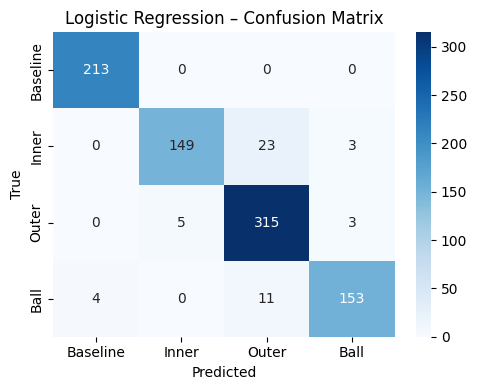


Saved:
  Logistic Regression model -> C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\logreg_stft_band.pkl
  Scaler                    -> C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\scaler_stft_band.pkl
  Predictions/results NPZ   -> C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\logreg_stft_band_results.npz


In [17]:
# 14. Logistic Regression on STFT-band features + SAVE RESULTS

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# 1) Standardize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_feat)
X_test_sc  = scaler.transform(X_test_feat)

# 2) Train multinomial Logistic Regression
logreg = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    random_state=SEED
)
logreg.fit(X_train_sc, y_train)

# 3) Evaluate on test set
y_pred_lr = logreg.predict(X_test_sc)

print("=== Logistic Regression (STFT band features) ===")
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
PI_FIG_PATH = TABULAR_ROOT / "logistic_regression_confussion_matrix.png"
plt.savefig(PI_FIG_PATH, dpi=300)
plt.show()

# 4) SAVE model, scaler, and predictions
LOGREG_MODEL_PATH = TABULAR_ROOT / "logreg_stft_band.pkl"
SCALER_PATH       = TABULAR_ROOT / "scaler_stft_band.pkl"
RESULTS_NPZ_PATH  = TABULAR_ROOT / "logreg_stft_band_results.npz"

joblib.dump(logreg, LOGREG_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

np.savez(
    RESULTS_NPZ_PATH,
    y_test=y_test,
    y_pred_lr=y_pred_lr,
    class_names=np.array(CLASS_NAMES, dtype=object)
)

print("\nSaved:")
print("  Logistic Regression model ->", LOGREG_MODEL_PATH)
print("  Scaler                    ->", SCALER_PATH)
print("  Predictions/results NPZ   ->", RESULTS_NPZ_PATH)


In [18]:
#15. Setup for interpretability 

plt.rcParams["figure.figsize"] = (8, 5)

# Feature and class names
feature_names = col_names 
class_names = ["Baseline", "Inner", "Outer", "Ball"]

print("n_features:", len(feature_names))
print(feature_names)


n_features: 15
['Band1_mean', 'Band1_rms', 'Band1_var', 'Band1_skew', 'Band1_kurt', 'Band2_mean', 'Band2_rms', 'Band2_var', 'Band2_skew', 'Band2_kurt', 'Band3_mean', 'Band3_rms', 'Band3_var', 'Band3_skew', 'Band3_kurt']


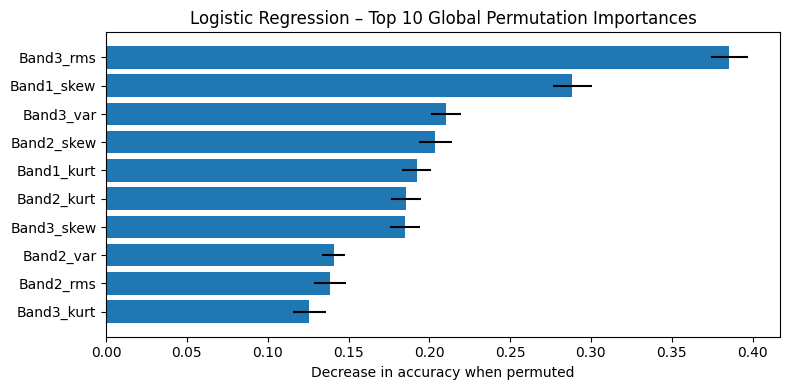


Saved:
  Permutation importance figure -> C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\logreg_perm_importance_top10.png
  Permutation importance arrays -> C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\logreg_perm_importance.npz

Top-10 features by permutation importance:
Band3_rms             mean=+0.3857  std=0.0114
Band1_skew            mean=+0.2885  std=0.0120
Band3_var             mean=+0.2103  std=0.0093
Band2_skew            mean=+0.2037  std=0.0102
Band1_kurt            mean=+0.1922  std=0.0090
Band2_kurt            mean=+0.1856  std=0.0093
Band3_skew            mean=+0.1849  std=0.0095
Band2_var             mean=+0.1408  std=0.0072
Band2_rms             mean=+0.1386  std=0.0100
Band3_kurt            mean=+0.1258  std=0.0102


In [20]:
# 16. Global Permutation Importance (Logistic Regression)

# 1) Compute permutation importances
perm_lin = permutation_importance(
    logreg,
    X_test_sc,       
    y_test,
    n_repeats=50,
    random_state=42
)

pi_mean = perm_lin.importances_mean
pi_std  = perm_lin.importances_std

# 2) Sort features by importance (descending)
sorted_idx = np.argsort(pi_mean)[::-1]

top_k = 10
top_idx = sorted_idx[:top_k]

feat_top = [feature_names[i] for i in top_idx]
pi_top   = pi_mean[top_idx]
std_top  = pi_std[top_idx]

# 3) Plot permutation importance (Top-K)
plt.figure(figsize=(8, 4))
plt.barh(feat_top, pi_top, xerr=std_top)
plt.gca().invert_yaxis()
plt.title("Logistic Regression – Top 10 Global Permutation Importances")
plt.xlabel("Decrease in accuracy when permuted")
plt.tight_layout()

# Save figure
PI_FIG_PATH = TABULAR_ROOT / "logreg_perm_importance_top10.png"
plt.savefig(PI_FIG_PATH, dpi=300)
plt.show()

# 4) Save permutation importance arrays
PI_NPZ_PATH = TABULAR_ROOT / "logreg_perm_importance.npz"

np.savez(
    PI_NPZ_PATH,
    pi_mean=pi_mean,
    pi_std=pi_std,
    feature_names=np.array(feature_names, dtype=object),
    top_idx=top_idx,
    top_features=np.array(feat_top, dtype=object),
    top_mean=pi_top,
    top_std=std_top
)

print("\nSaved:")
print("  Permutation importance figure ->", PI_FIG_PATH)
print("  Permutation importance arrays ->", PI_NPZ_PATH)

# 5) Print summary
print("\nTop-10 features by permutation importance:")
for name, m, s in zip(feat_top, pi_top, std_top):
    print(f"{name:20s}  mean={m:+.4f}  std={s:.4f}")



=== Local explanation for class 'Baseline' (test sample #270) ===
Saved local explanation figure to: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\local_explanations\local_logit_sample270_trueBaseline_predBaseline.png


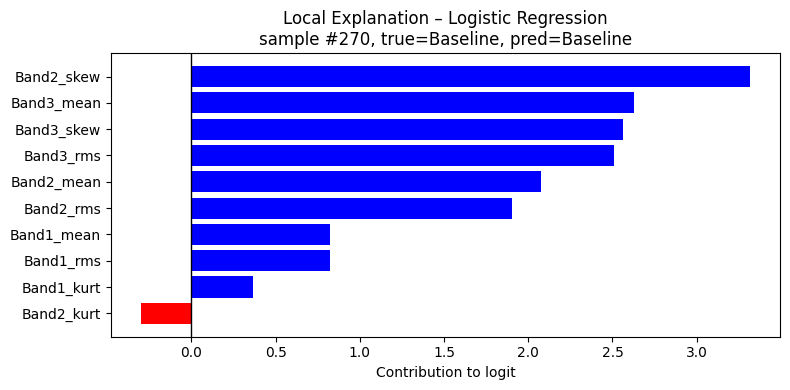


=== Local explanation for class 'Inner' (test sample #394) ===
Saved local explanation figure to: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\local_explanations\local_logit_sample394_trueInner_predInner.png


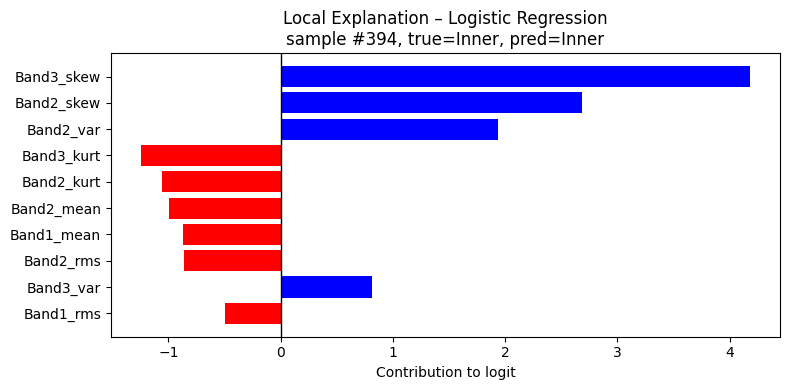


=== Local explanation for class 'Outer' (test sample #176) ===
Saved local explanation figure to: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\local_explanations\local_logit_sample176_trueOuter_predOuter.png


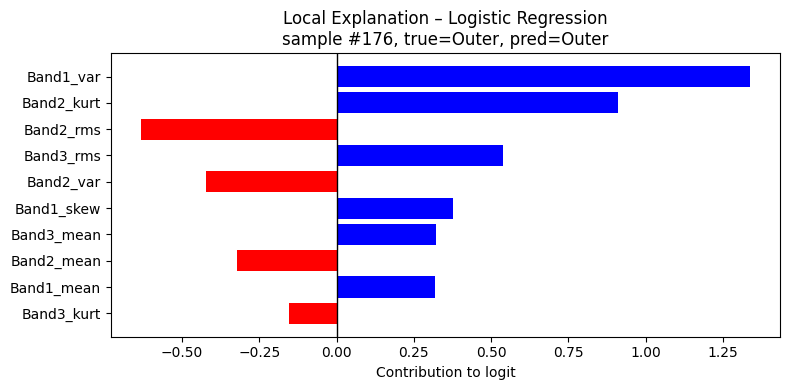


=== Local explanation for class 'Ball' (test sample #378) ===
Saved local explanation figure to: C:\Users\Nicolas\XAI\COE691_XAI_Project_Nicolas\tabular_models_outputs\local_explanations\local_logit_sample378_trueBall_predBall.png


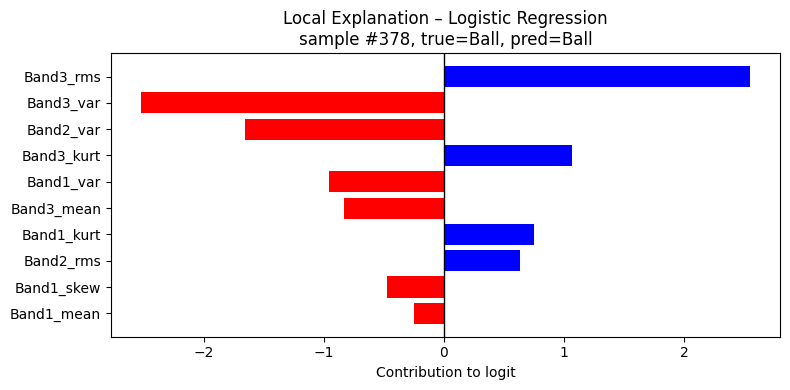

In [21]:
# 17. Local explanations – per-sample logit contributions

def plot_local_logit_contributions(idx, model, X_sc, y_true,
                                   feature_names, class_names,
                                   top_n=10,
                                   save_dir=None):
    
    x = X_sc[idx]  # (n_features,)

    # Decision function gives logits (one per class)
    logits = model.decision_function(X_sc[idx:idx+1])[0]  # (n_classes,)
    pred_class = int(np.argmax(logits))
    true_class = int(y_true[idx])

    # Per-feature contribution to the predicted-class logit:
    # logit_k = w_k · x + b_k  ->  contribution_j = w_kj * x_j
    w_k = model.coef_[pred_class]          # (n_features,)
    contrib = x * w_k                      # (n_features,)

    # Sort by absolute contribution
    order = np.argsort(np.abs(contrib))[::-1][:top_n]
    feat_sel = np.array(feature_names)[order]
    contrib_sel = contrib[order]

    colors = ["blue" if c > 0 else "red" for c in contrib_sel]

    plt.figure(figsize=(8, 4))
    plt.barh(feat_sel, contrib_sel, color=colors)
    plt.gca().invert_yaxis()
    plt.axvline(0.0, color="k", linewidth=1)
    plt.xlabel("Contribution to logit")
    plt.title(
        f"Local Explanation – Logistic Regression\n"
        f"sample #{idx}, true={class_names[true_class]}, "
        f"pred={class_names[pred_class]}"
    )
    plt.tight_layout()

    # Save figure if a folder is provided
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = f"local_logit_sample{idx}_true{class_names[true_class]}_pred{class_names[pred_class]}.png"
        fig_path = save_dir / fname
        plt.savefig(fig_path, dpi=300)
        print("Saved local explanation figure to:", fig_path)

    plt.show()

# === Generate one explanation per class ===

y_pred_full = logreg.predict(X_test_sc)
n_classes = len(CLASS_NAMES)

LOCAL_EXPL_ROOT = TABULAR_ROOT / "local_explanations"
LOCAL_EXPL_ROOT.mkdir(parents=True, exist_ok=True)

for c in range(n_classes):
    idx_candidates = np.where((y_test == c) & (y_pred_full == c))[0]
    if len(idx_candidates) == 0:
        # use any sample of that class (even if misclassified)
        idx_candidates = np.where(y_test == c)[0]

    idx_example = int(idx_candidates[69])

    print(f"\n=== Local explanation for class '{CLASS_NAMES[c]}' "
          f"(test sample #{idx_example}) ===")

    plot_local_logit_contributions(
        idx_example,
        logreg,
        X_test_sc,
        y_test,
        feature_names,
        CLASS_NAMES,
        top_n=10,
        save_dir=LOCAL_EXPL_ROOT
    )
